# Run artworks example

This notebook implements a quick inference on the labeled examples. Since the examples source code are now stored in a JSON file, and not into seperate files, we have this notebook to not interfeer with he code that will be used to run on the new source code files.

## Imports, configs and read data

In [1]:
import json
import yaml
from Model import LLM_Model
from Prompts import *
from collections import Counter
import matplotlib.pyplot as plt

def get_prompt_template(prompt_version):
    return globals()[prompt_version].template

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})

        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return dict(counter)


def count_all_labels(examples):
    return {
        "classification": count_labels(examples, "classification"),
        "predicted_classification": count_labels(examples, "predicted_classification"),
    }

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})
        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return counter


def plot_all_distributions(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    all_labels = sorted(set(true_counts) | set(pred_counts))
    x = range(len(all_labels))
    width = 0.4

    plt.figure(figsize=(12, 5))
    plt.bar([i - width/2 for i in x], [true_counts.get(label, 0) for label in all_labels], width=width, label="classification")
    plt.bar([i + width/2 for i in x], [pred_counts.get(label, 0) for label in all_labels], width=width, label="predicted_classification")

    plt.xticks(x, all_labels, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title("Classification vs Predicted Classification")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_distributions_by_dimension(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    for dimension in ["entities", "interaction", "outcome"]:
        labels = sorted([
            key.split("_", 1)[1]
            for key in set(true_counts) | set(pred_counts)
            if key.startswith(f"{dimension}_")
        ])

        x = range(len(labels))
        width = 0.4

        plt.figure(figsize=(8, 4)) 
        plt.bar([i - width/2 for i in x], [true_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="classification")
        plt.bar([i + width/2 for i in x], [pred_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="predicted_classification")

        plt.xticks(x, labels, rotation=45, ha="right")
        plt.ylabel("Count")
        plt.title(f"{dimension}: classification vs predicted")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [2]:
# Read configs
print("Configs...")
with open("../config.yml", "r") as f:
    configs = yaml.safe_load(f)

config_mode = configs["chosen_config"]['config_mode']
model = configs["chosen_config"]["model"]

Configs...


In [3]:
# Read examples
with open("../examples/artworks_corrected_classif.json") as f:
    examples = json.load(f)

# Print one examples
# examples[0]

In [4]:
llm_model = LLM_Model(
    model_name=configs[model]['model_name'],
    base_url=configs[model]['base_url'],
    system_prompt=configs[model]['system_prompt']
)

## Inference

In [12]:
prompt_version = "PROMPT_11"
prompt = get_prompt_template(prompt_version)

# print("Using this prompt:\n", prompt)

for i, artwork in enumerate(examples):
    # Read src code
    art_src_code = artwork['metadata']['content']

    # Pass it to LLM
    predicted_labels = llm_model.get_labels(
        prompt_template=prompt, 
        art_src_code=art_src_code, 
        system_prompt=llm_model.system_prompt
    )
    if isinstance(predicted_labels.get("interaction"), str):
        predicted_labels["interaction"] = [predicted_labels["interaction"]]
    # print("Actual labels:", artwork['classification'])
    # print("Predicted labels:", predicted_labels)

    # Add prediction back to the json
    examples[i]["predicted_classification"] = predicted_labels
    

## Data Viz

In [10]:
results = count_all_labels(examples)

results["classification"]
results["predicted_classification"]

Counter({'outcome_visual': 73,
         'entities_synthesized_image': 71,
         'outcome_time_based': 64,
         'entities_randomness': 59,
         'interaction_no': 45,
         'interaction_yes': 29,
         'entities_processed_image': 12,
         'outcome_auditory': 10,
         'outcome_static': 10,
         'entities_processed_audio': 7,
         'entities_synthesized_text': 7,
         'entities_synthesized_sound': 4,
         'entities_processed_text': 2,
         'entities_processed_font': 1,
         'entities_visual': 1,
         'entities_time_based': 1})

prompt 10


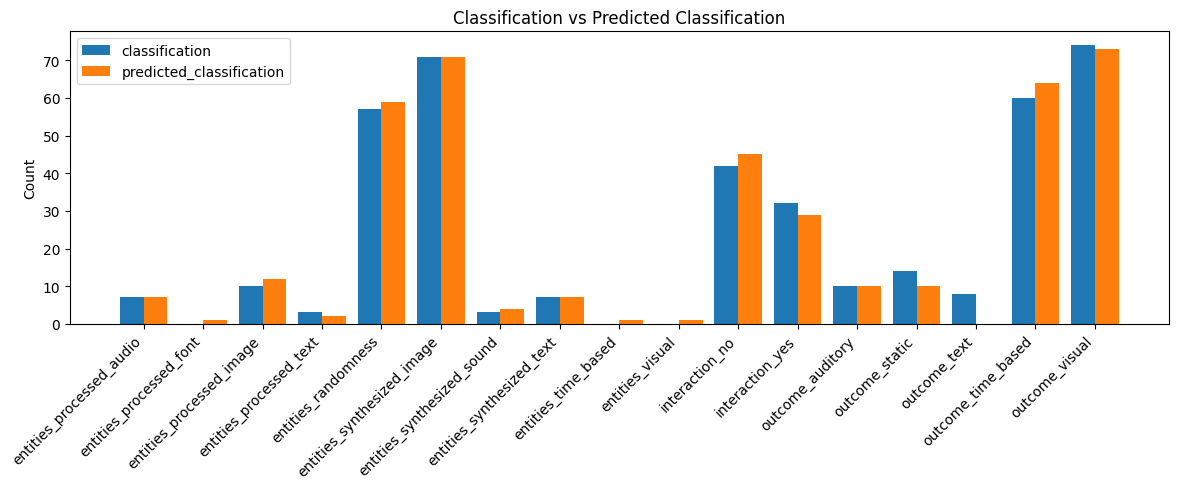

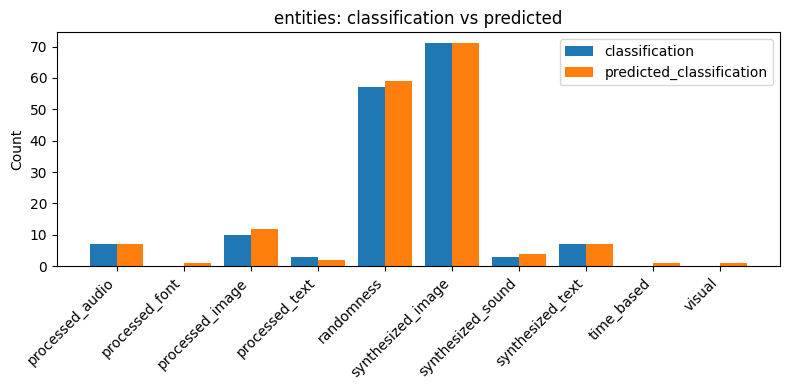

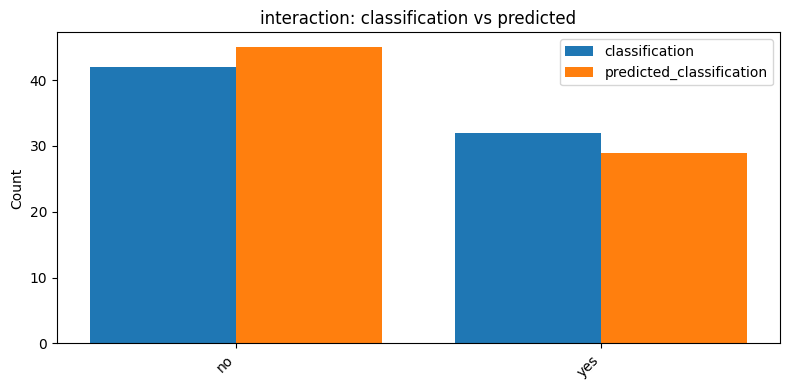

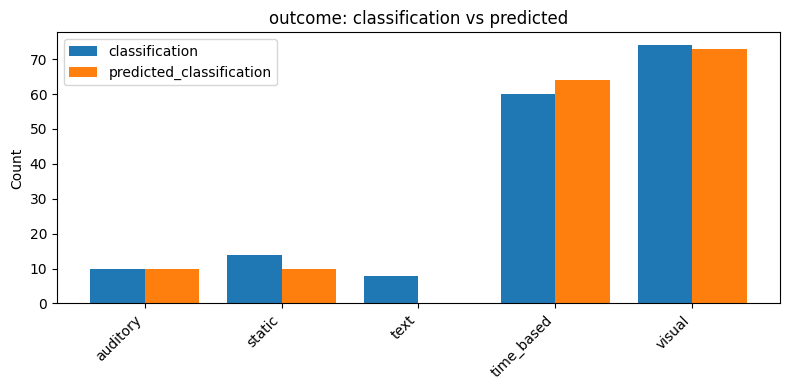

In [11]:
plot_all_distributions(examples)
plot_distributions_by_dimension(examples)

---

Prompt 11

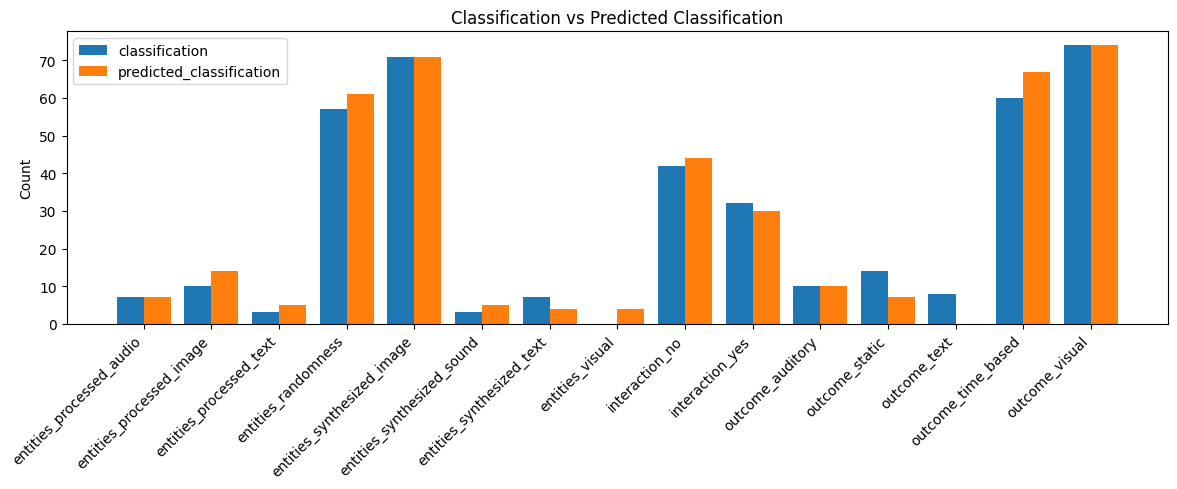

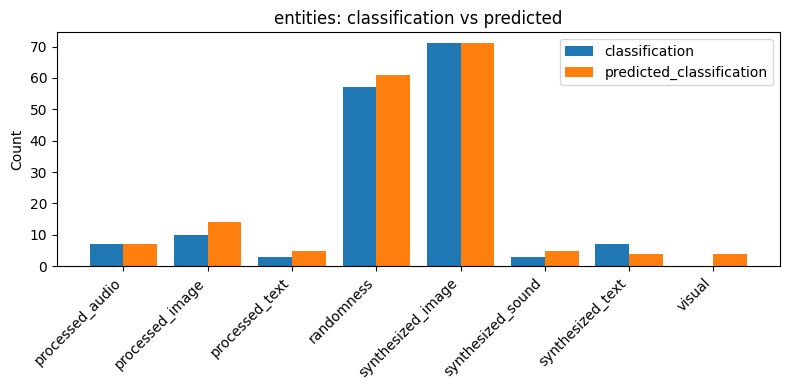

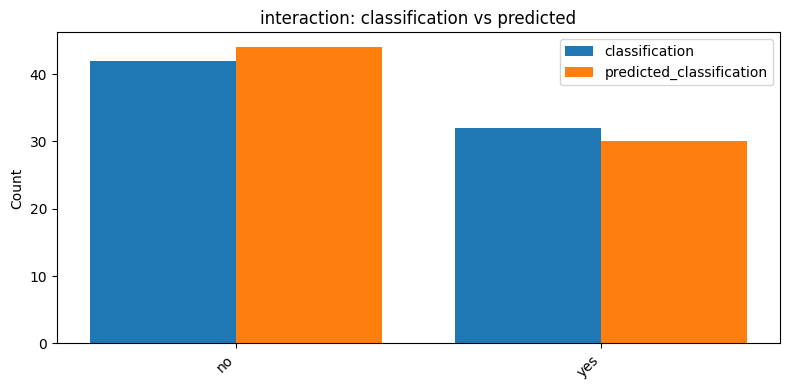

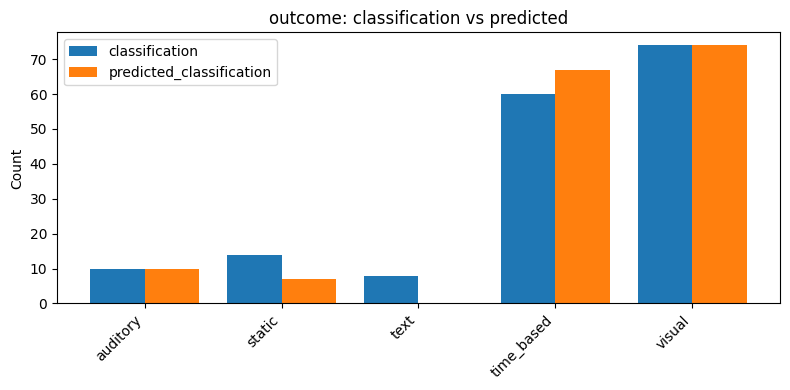

In [14]:
plot_all_distributions(examples)
plot_distributions_by_dimension(examples)

In [8]:
def filter_by_classification(
    items,
    classification_field="predicted_classification", 
    key="outcome",
    values=None,
    mode="any",
):
    if values is None:
        raise ValueError("You must provide `values`.")

    if isinstance(values, str):
        values = [values]

    target_values = set(values)
    filtered = []

    for item in items:
        classif = item.get(classification_field, {})
        current = classif.get(key, [])

        if isinstance(current, str):
            current = [current]

        current_set = set(current)

        if mode == "any":
            keep = bool(current_set & target_values)
        elif mode == "all":
            keep = target_values.issubset(current_set)
        elif mode == "exact":
            keep = current_set == target_values
        else:
            raise ValueError("mode must be 'any', 'all', or 'exact'")

        if keep:
            filtered.append(item)

    return filtered

In [9]:
# filter_by_classification(
#     examples,
#     classification_field="classification",
#     key="entities",
#     values="randomness",
#     mode="any"
# )

In [10]:
with open("examples_prompt8.json", "w", encoding="utf-8") as f:
    json.dump(examples, f, ensure_ascii=False, indent=2)

In [11]:
def find_missed_label_examples(
    items,
    key="entities",
    value="randomness",
    actual_field="classification",
    predicted_field="predicted_classification",
):
    """
    Return items where the true label contains `value`
    but the predicted label does not.
    """
    results = []

    for item in items:
        actual = item.get(actual_field, {}).get(key, [])
        predicted = item.get(predicted_field, {}).get(key, [])

        if isinstance(actual, str):
            actual = [actual]
        if isinstance(predicted, str):
            predicted = [predicted]

        if value in actual and value not in predicted:
            results.append(item)

    return results

In [12]:
find_missed_label_examples(
    examples,
    key="interaction",
    value="yes"
)

[{'id': 'A30',
  'title': 'Week_6_3D_WEBGL_sketch',
  'artist': 'cleonc13',
  'year': '2020',
  'repoUrl': 'https://github.com/cleonc13/Creative-Coding-Projects',
  'classification': {'entities': ['processed_image', 'synthesized_image'],
   'interaction': ['yes'],
   'outcome': ['visual', 'time_based']},
  'description': 'A generative landscape created using Perlin noise.',
  'llm_notes': 'Relies on Perlin noise to produce smooth organic shapes resembling a landscape.',
  'metadata': {'file_name': 'Week_6_3D_WEBGL_sketch',
   'extension': '.js',
   'content': "function setup() {\n  createCanvas(400, 400, WEBGL);\n  img = loadImage('Galaxys.jpg'); //texture\n}\n\nfunction draw() {\n  background(0);\n  \n  \n  push();\n  //ambientLight(205, 0, 0);\n  rotateZ(frameCount - 0.01);\n  //rotateX(frameCount * 0.01);\n  rotateY(frameCount * 0.01);\n  texture(img);\n  box(25);\n  pop();\n  \n  push();\n  ambientLight(225, 225, 0); //light (supposed to be yellow)\n  \n  translate(69, 0)\n  //norm

---

Prompt 7

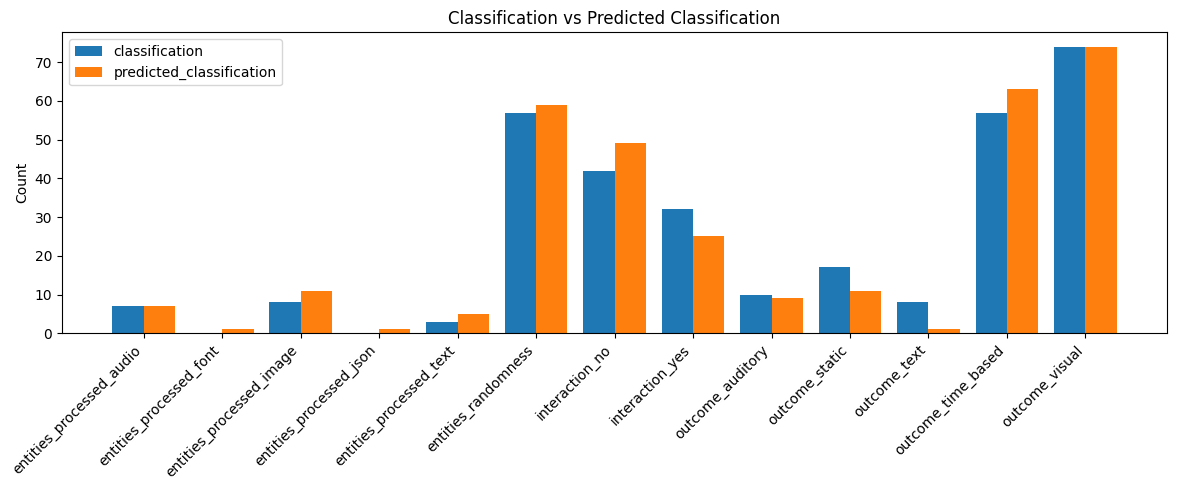

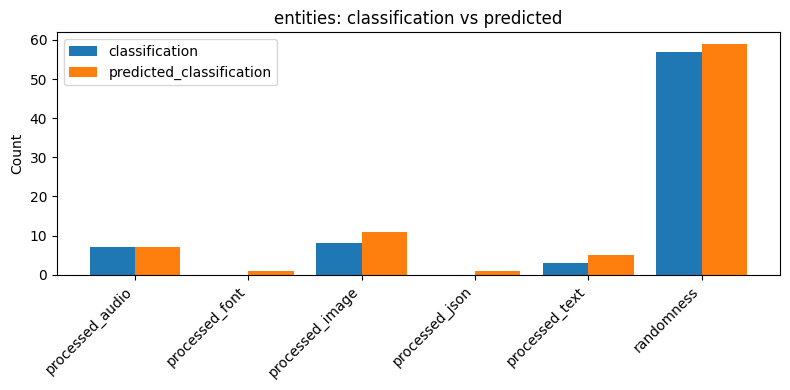

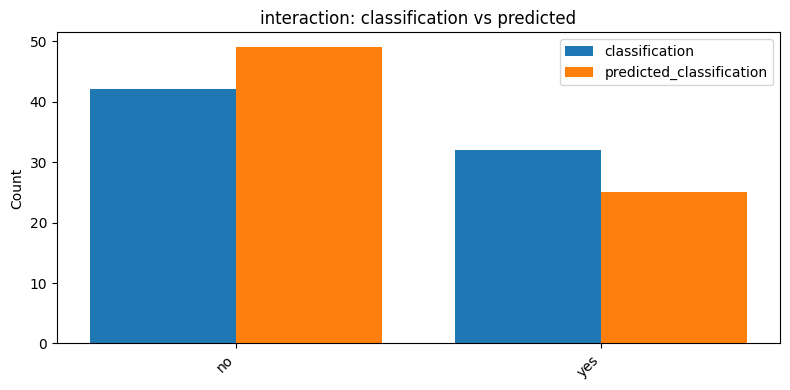

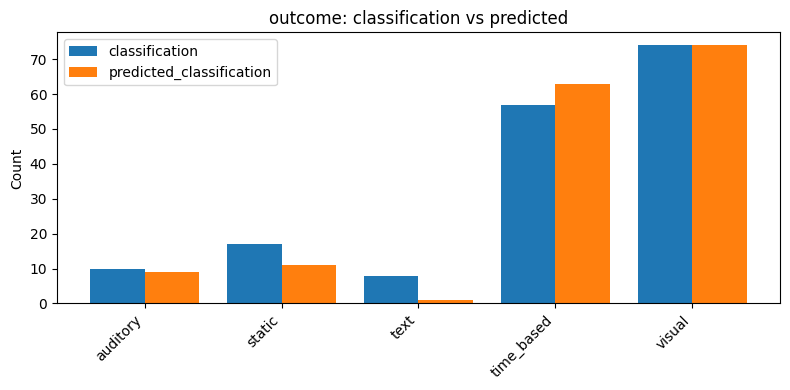

In [7]:
plot_all_distributions(examples)
plot_distributions_by_dimension(examples)

In [10]:
with open("examples_prompt8.json", "w", encoding="utf-8") as f:
    json.dump(examples, f, ensure_ascii=False, indent=2)

In [18]:
examples

[{'id': 'A1',
  'title': 'black&white_rotate',
  'artist': 'Benoit Baudry',
  'repoUrl': 'None',
  'year': '2020',
  'classification': {'entities': ['synthesized_image', 'randomness'],
   'interaction': ['no'],
   'outcome': ['visual', 'time_based']},
  'description': 'A generative landscape created using Perlin noise.',
  'llm_notes': 'Relies on Perlin noise to produce smooth organic shapes resembling a landscape.',
  'metadata': {'file_name': 'black&white_rotate',
   'extension': '.js',
   'content': 'let canvasWidth = 800;\nlet canvasHeight = 800;\nlet topLayer;\nlet bottomLayer;\nlet startX = -canvasWidth; // Start off-screen\nlet weightDifference;\nlet blackWeight;\nlet whiteWeight;\nlet maskGraphics; \n\n\nfunction setup() {\n  createCanvas(canvasWidth, canvasHeight);\n\n  topLayer = createGraphics(canvasWidth, canvasHeight); \n  bottomLayer = createGraphics(canvasWidth, canvasHeight); \n\n  weightDifference = random(-5, 5);\n  blackWeight = random(5, 20);\n  whiteWeight = blackW